<a href="https://colab.research.google.com/github/Hamerson-jhoel/TOPICOS-VISION-ARTIFICIAL/blob/main/Actividad2/Canales_RGB_DNG_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extraccion de canales R, G, B de fotos RAW (.dng) tomadas con luz de color

Sube 4 fotos `.dng` (RAW) tomadas con el celular bajo distinta iluminacion (luz roja, verde, azul, y brillo maximo/blanco). Para cada foto se extraen y se guardan por separado sus **3 componentes de color: R (rojo), G (verde), B (azul)**, para ver como cambia la intensidad de cada canal segun el color de luz.

**Importante:** se decodifica el RAW **sin balance de blancos automatico** (`use_camera_wb=False, use_auto_wb=False`) y **sin brillo automatico** (`no_auto_bright=True`). Si se dejara el balance de blancos activado, la camara/celular intentaria "corregir" el tinte de color de la luz automaticamente, y las diferencias entre canales que quieres estudiar desaparecerian del RAW antes de que las veas.

In [ ]:
!pip -q install rawpy imageio --upgrade

import rawpy, os, glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("rawpy version:", rawpy.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.1/328.1 kB 12.2 MB/s eta 0:00:00
rawpy version: 0.27.1


## 1. Subir las 4 fotos `.dng`

Nombra los archivos de forma que se reconozca el color de luz usada, por ejemplo: `rojo.dng`, `verde.dng`, `azul.dng`, `blanco.dng` (o `brillo.dng`). Si el nombre no coincide con ninguna palabra clave, se usa el nombre del archivo tal cual como etiqueta.

In [ ]:
from google.colab import files

BASE_DIR = "/content/fotos_dng"
os.makedirs(BASE_DIR, exist_ok=True)

print("Selecciona tus 4 archivos .dng...")
uploaded = files.upload()

rutas = []
for fname in uploaded.keys():
    dst = os.path.join(BASE_DIR, fname)
    if os.path.abspath(fname) != os.path.abspath(dst):
        os.replace(fname, dst)
    rutas.append(dst)

rutas = sorted([r for r in rutas if r.lower().endswith((".dng", ".raw"))])
print(f"\n{len(rutas)} archivo(s) DNG cargado(s):")
for r in rutas:
    print(" -", os.path.basename(r))

assert len(rutas) >= 1, "No se subio ningun archivo .dng"


Selecciona tus 4 archivos .dng...


Saving blanco.dng to blanco.dng
Saving verde.dng to verde.dng
Saving rojo.dng to rojo.dng
Saving azul.dng to azul.dng

4 archivo(s) DNG cargado(s):
 - azul.dng
 - blanco.dng
 - rojo.dng
 - verde.dng


## 2. Etiquetar cada foto segun el color de luz

Se detecta automaticamente por palabras clave en el nombre del archivo. Si alguna no se reconoce, ajusta manualmente el diccionario `ETIQUETAS` que se imprime al final de esta celda.

In [ ]:
PALABRAS_CLAVE = {
    "rojo": "Luz roja", "red": "Luz roja",
    "verde": "Luz verde", "green": "Luz verde",
    "azul": "Luz azul", "blue": "Luz azul",
    "blanco": "Brillo maximo / blanco", "brillo": "Brillo maximo / blanco",
    "white": "Brillo maximo / blanco", "max": "Brillo maximo / blanco",
}

def etiquetar(nombre_archivo):
    base = os.path.splitext(os.path.basename(nombre_archivo))[0].lower()
    for clave, etiqueta in PALABRAS_CLAVE.items():
        if clave in base:
            return etiqueta
    return os.path.basename(nombre_archivo)  # si no reconoce nada, usa el nombre tal cual

ETIQUETAS = {r: etiquetar(r) for r in rutas}
print("Etiquetas detectadas:")
for r, e in ETIQUETAS.items():
    print(f"  {os.path.basename(r):25s} -> {e}")

# Si alguna etiqueta salio mal, corrigela aqui a mano, por ejemplo:
# ETIQUETAS["/content/fotos_dng/IMG_0001.dng"] = "Luz roja"


Etiquetas detectadas:
  azul.dng                  -> Luz azul
  blanco.dng                -> Brillo maximo / blanco
  rojo.dng                  -> Luz roja
  verde.dng                 -> Luz verde


## 3. Decodificar el RAW y extraer los 3 canales (R, G, B)

`raw.postprocess(...)` hace el demosaico del sensor (convierte el patron de Bayer crudo en una imagen RGB completa). Con `use_camera_wb=False, use_auto_wb=False, no_auto_bright=True` se evita cualquier correccion automatica de color/brillo, para conservar las diferencias reales causadas por la luz de color.

In [ ]:
def cargar_raw_como_rgb(path, bps=8):
    with rawpy.imread(path) as raw:
        rgb = raw.postprocess(
            use_camera_wb=False,
            use_auto_wb=False,
            no_auto_bright=True,
            output_bps=bps,
            gamma=(1, 1),          # sin correccion de gamma: valores lineales, mas fieles al sensor
        )
    return rgb  # array HxWx3, dtype uint8 (o uint16 si bps=16)

def separar_canales(rgb):
    """Devuelve 3 imagenes en escala de grises, una por canal (R, G, B)."""
    R = rgb[:, :, 0]
    G = rgb[:, :, 1]
    B = rgb[:, :, 2]
    return R, G, B

datos = {}  # nombre_archivo -> (rgb, R, G, B)
for r in rutas:
    print(f"Decodificando: {os.path.basename(r)} ({ETIQUETAS[r]})...")
    rgb = cargar_raw_como_rgb(r)
    R, G, B = separar_canales(rgb)
    datos[r] = (rgb, R, G, B)
    print(f"  tamano: {rgb.shape[1]}x{rgb.shape[0]} px")

print("\nListo, se decodificaron", len(datos), "foto(s).")


Decodificando: azul.dng (Luz azul)...
  tamano: 3072x4096 px
Decodificando: blanco.dng (Brillo maximo / blanco)...
  tamano: 3072x4096 px
Decodificando: rojo.dng (Luz roja)...
  tamano: 3072x4096 px
Decodificando: verde.dng (Luz verde)...
  tamano: 3072x4096 px

Listo, se decodificaron 4 foto(s).


## 4. Guardar cada componente como imagen individual

Por cada foto se guardan 4 archivos: la foto RGB completa (para referencia) y sus 3 canales por separado en escala de grises (`_R.png`, `_G.png`, `_B.png`).

In [ ]:
import imageio.v2 as imageio

OUT_DIR = "/content/canales_rgb"
os.makedirs(OUT_DIR, exist_ok=True)

for r in rutas:
    rgb, R, G, B = datos[r]
    base = os.path.splitext(os.path.basename(r))[0]

    imageio.imwrite(os.path.join(OUT_DIR, f"{base}_RGB.png"), rgb)
    imageio.imwrite(os.path.join(OUT_DIR, f"{base}_R.png"), R)
    imageio.imwrite(os.path.join(OUT_DIR, f"{base}_G.png"), G)
    imageio.imwrite(os.path.join(OUT_DIR, f"{base}_B.png"), B)

print("Imagenes guardadas en:", OUT_DIR)
for f in sorted(os.listdir(OUT_DIR)):
    print("  -", f)


Imagenes guardadas en: /content/canales_rgb
  - azul_B.png
  - azul_G.png
  - azul_R.png
  - azul_RGB.png
  - blanco_B.png
  - blanco_G.png
  - blanco_R.png
  - blanco_RGB.png
  - rojo_B.png
  - rojo_G.png
  - rojo_R.png
  - rojo_RGB.png
  - verde_B.png
  - verde_G.png
  - verde_R.png
  - verde_RGB.png


## 5. Ver los 3 canales de cada foto, uno al lado del otro

Cada fila es una foto (una condicion de luz); las columnas son RGB completo, canal R, canal G y canal B. **Los 3 canales se muestran en escala de grises (`cmap="gray"`), igual que se guardaron en el paso 4** — el brillo de cada pixel es directamente el valor de intensidad de ese canal (0=negro, 255=blanco), sin ningun color agregado.

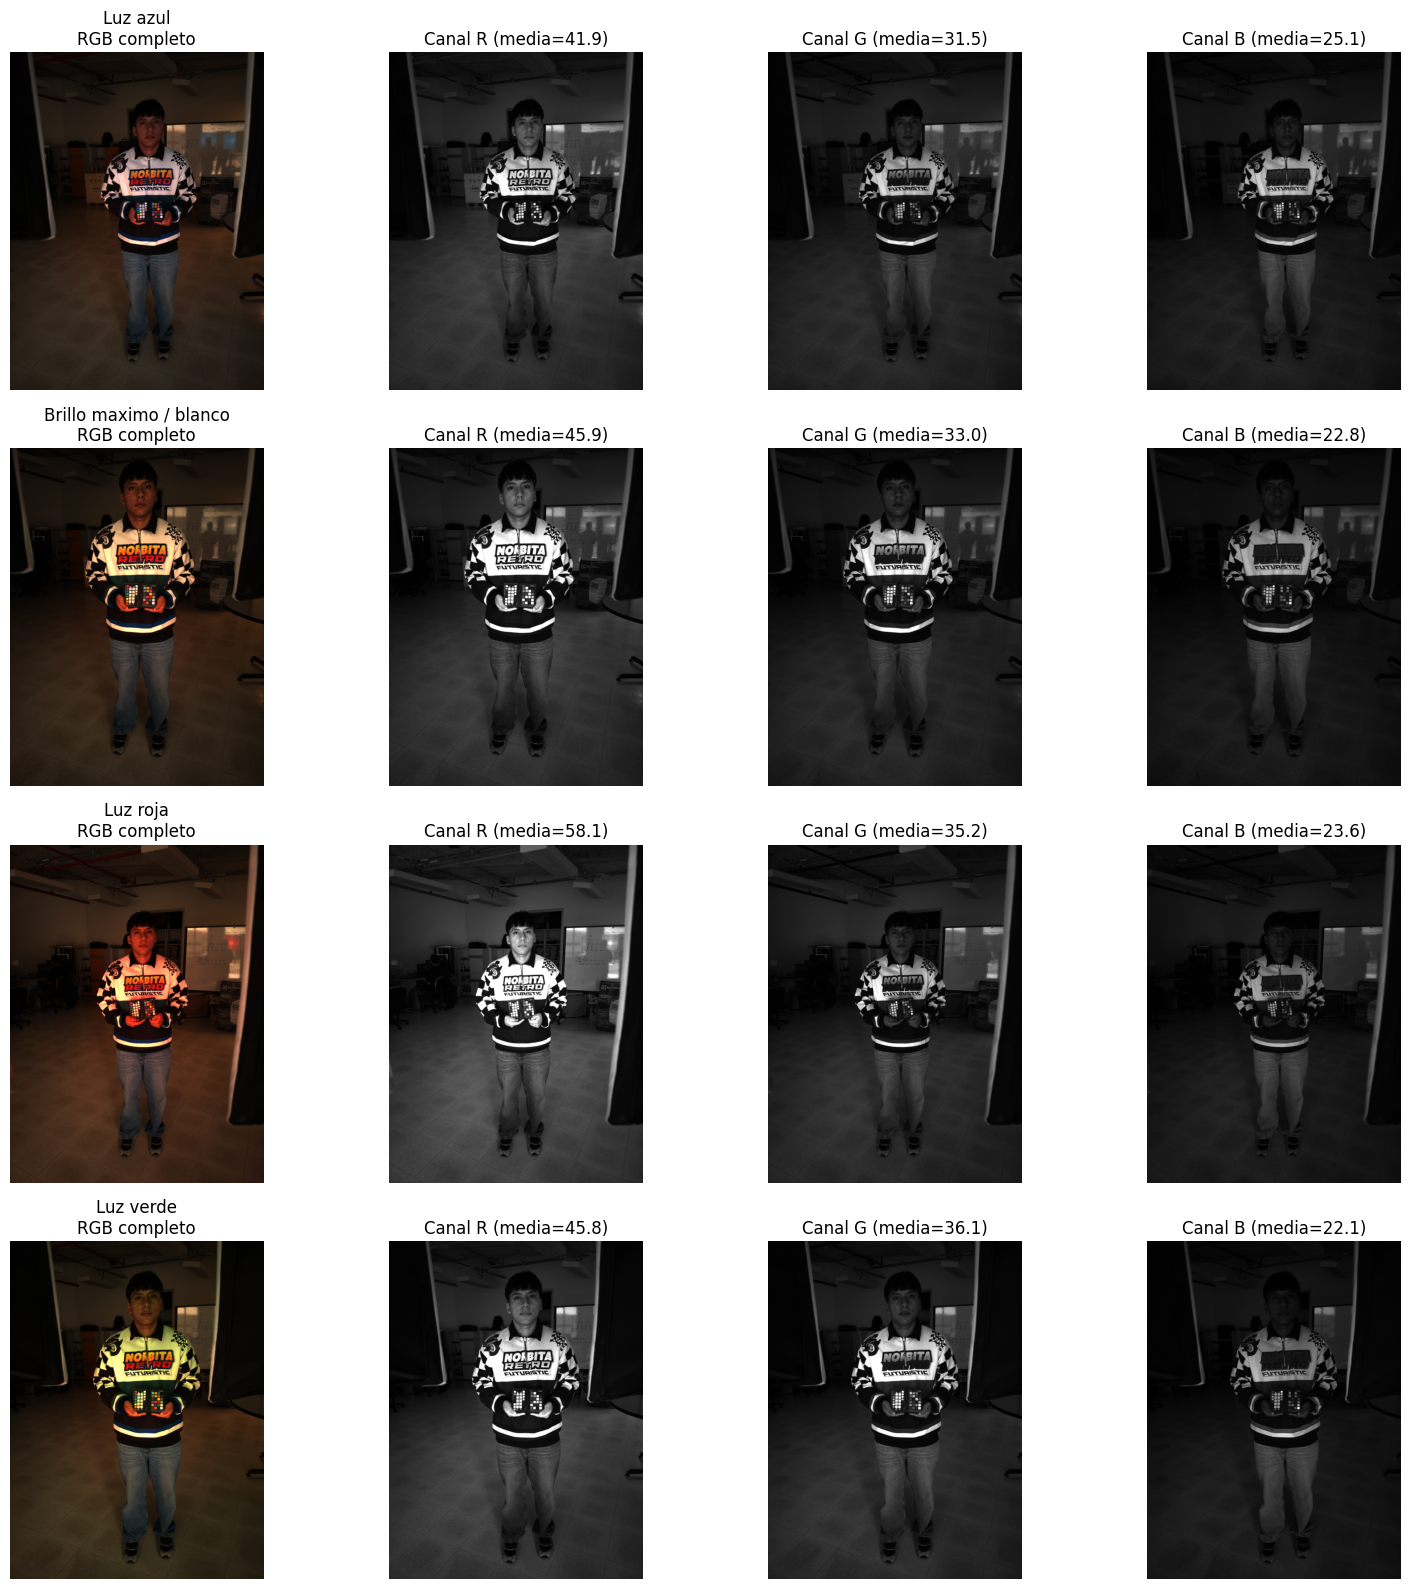

In [ ]:
n = len(rutas)
fig, axs = plt.subplots(n, 4, figsize=(16, 4 * n))
if n == 1:
    axs = axs[None, :]

for i, r in enumerate(rutas):
    rgb, R, G, B = datos[r]
    etiqueta = ETIQUETAS[r]

    axs[i, 0].imshow(rgb); axs[i, 0].set_title(f"{etiqueta}\nRGB completo"); axs[i, 0].axis("off")

    axs[i, 1].imshow(R, cmap="gray", vmin=0, vmax=255); axs[i, 1].set_title(f"Canal R (media={R.mean():.1f})"); axs[i, 1].axis("off")
    axs[i, 2].imshow(G, cmap="gray", vmin=0, vmax=255); axs[i, 2].set_title(f"Canal G (media={G.mean():.1f})"); axs[i, 2].axis("off")
    axs[i, 3].imshow(B, cmap="gray", vmin=0, vmax=255); axs[i, 3].set_title(f"Canal B (media={B.mean():.1f})"); axs[i, 3].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "comparacion_canales_gris.png"), dpi=120, bbox_inches="tight")
plt.show()


## 5.1 (Opcional) Vista coloreada — solo para interpretar mas facil en pantalla

Esta celda es puramente visual: colorea cada canal con su color correspondiente (R en rojo, G en verde, B en azul) para que sea mas intuitivo comparar a simple vista cual canal domina en cada foto. **No cambia ni reemplaza los archivos en escala de grises guardados en el paso 4** — es solo otra forma de mirar los mismos datos.

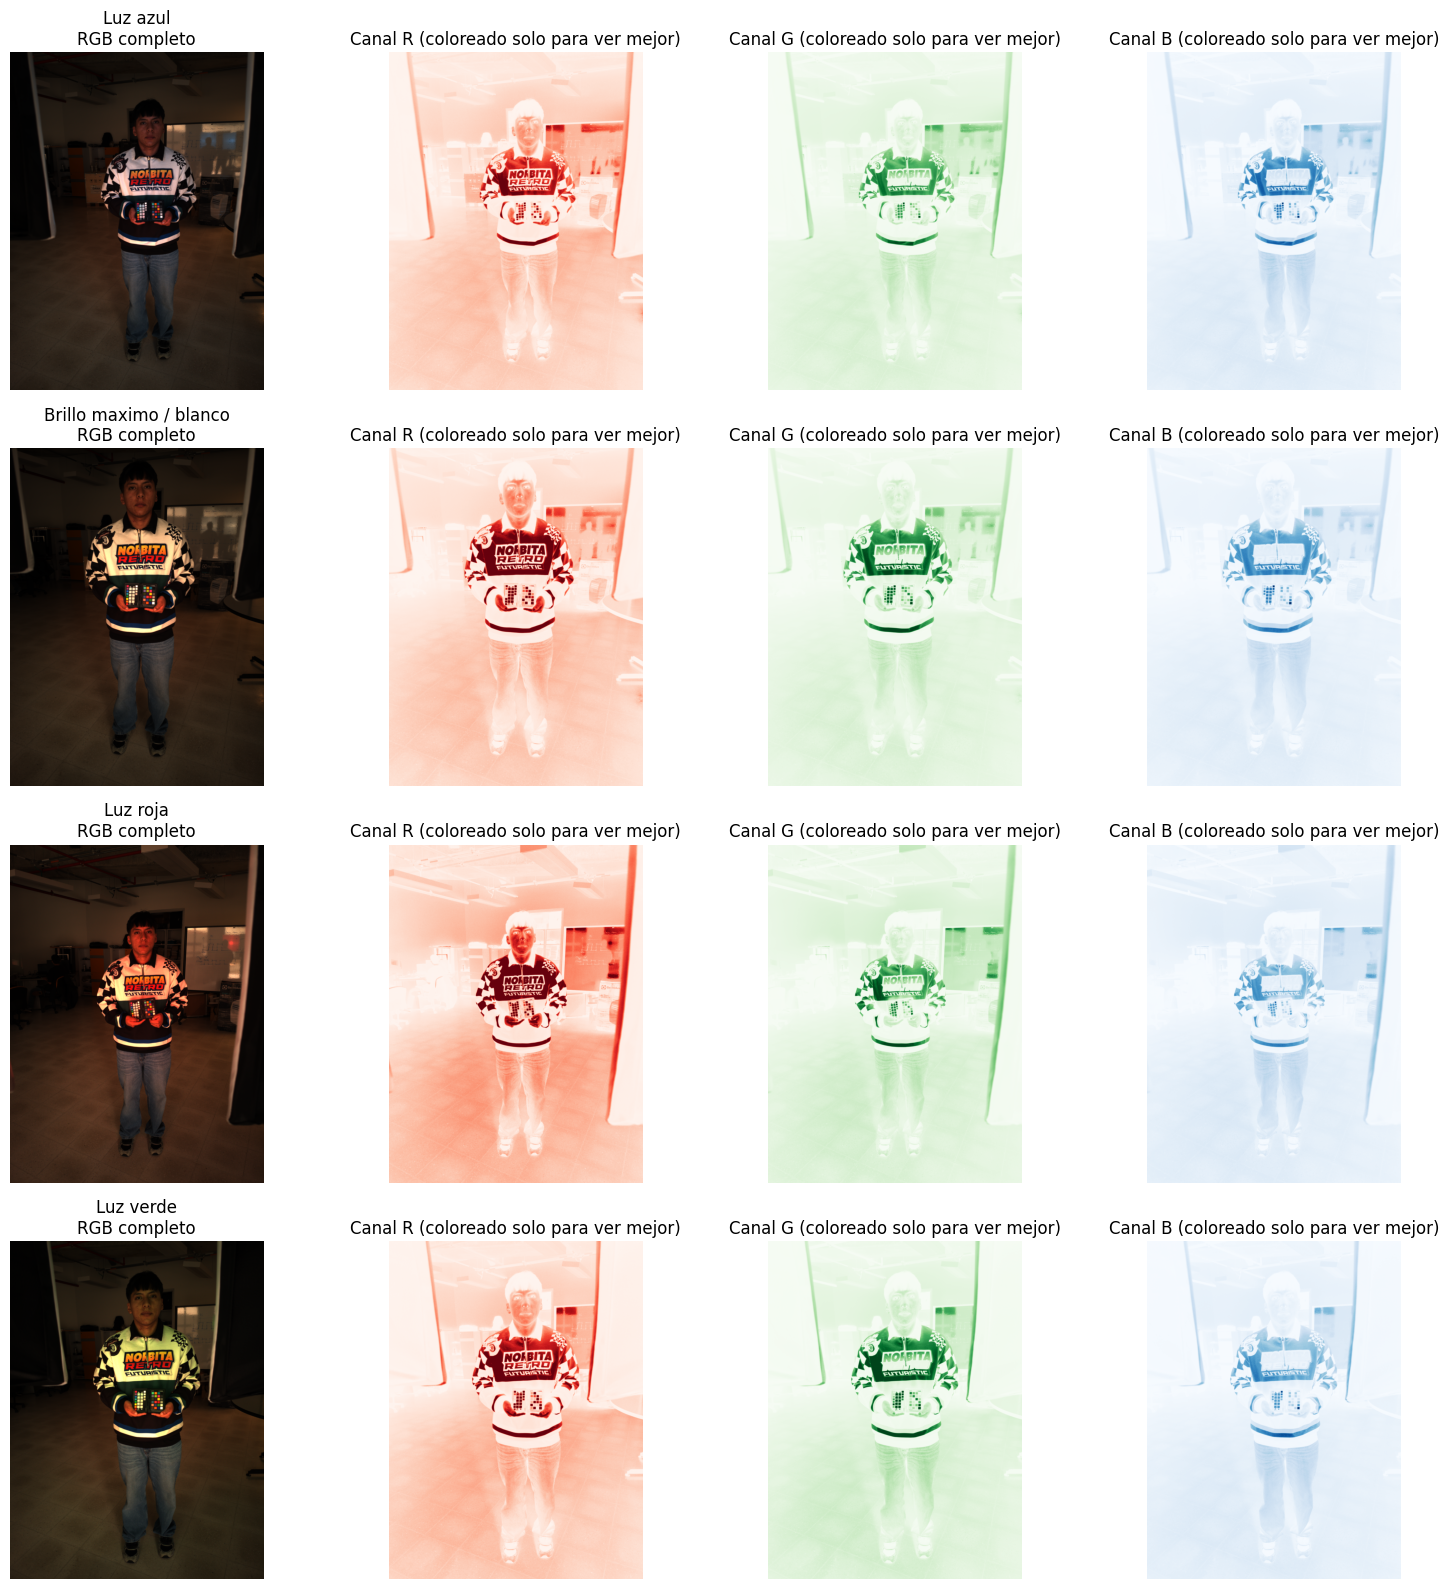

In [ ]:
fig, axs = plt.subplots(n, 4, figsize=(16, 4 * n))
if n == 1:
    axs = axs[None, :]

for i, r in enumerate(rutas):
    rgb, R, G, B = datos[r]
    etiqueta = ETIQUETAS[r]

    axs[i, 0].imshow(rgb); axs[i, 0].set_title(f"{etiqueta}\nRGB completo"); axs[i, 0].axis("off")
    axs[i, 1].imshow(R, cmap="Reds", vmin=0, vmax=255); axs[i, 1].set_title("Canal R (coloreado solo para ver mejor)"); axs[i, 1].axis("off")
    axs[i, 2].imshow(G, cmap="Greens", vmin=0, vmax=255); axs[i, 2].set_title("Canal G (coloreado solo para ver mejor)"); axs[i, 2].axis("off")
    axs[i, 3].imshow(B, cmap="Blues", vmin=0, vmax=255); axs[i, 3].set_title("Canal B (coloreado solo para ver mejor)"); axs[i, 3].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "comparacion_canales_coloreada.png"), dpi=120, bbox_inches="tight")
plt.show()


## 6. Tabla comparativa: como cambia cada canal segun la luz

Estadisticas (media y desviacion estandar de intensidad, 0-255) de cada canal, por foto. Es la forma mas directa de **cuantificar** el efecto que viste en las imagenes: por ejemplo, bajo luz roja se espera que el canal R tenga una media mucho mas alta que G y B.

In [ ]:
filas = []
for r in rutas:
    rgb, R, G, B = datos[r]
    filas.append({
        "condicion_luz": ETIQUETAS[r],
        "archivo": os.path.basename(r),
        "R_media": round(float(R.mean()), 2), "R_std": round(float(R.std()), 2),
        "G_media": round(float(G.mean()), 2), "G_std": round(float(G.std()), 2),
        "B_media": round(float(B.mean()), 2), "B_std": round(float(B.std()), 2),
    })

tabla_canales = pd.DataFrame(filas)
tabla_canales


,condicion_luz,archivo,R_media,R_std,G_media,G_std,B_media,B_std
0,Luz azul,azul.dng,41.90,35.99,31.48,28.40,25.11,26.81
1,Brillo maximo / blanco,blanco.dng,45.88,46.48,33.03,35.96,22.84,26.14
2,Luz roja,rojo.dng,58.12,47.71,35.16,30.67,23.58,21.63
3,Luz verde,verde.dng,45.81,44.62,36.11,39.34,22.11,23.80


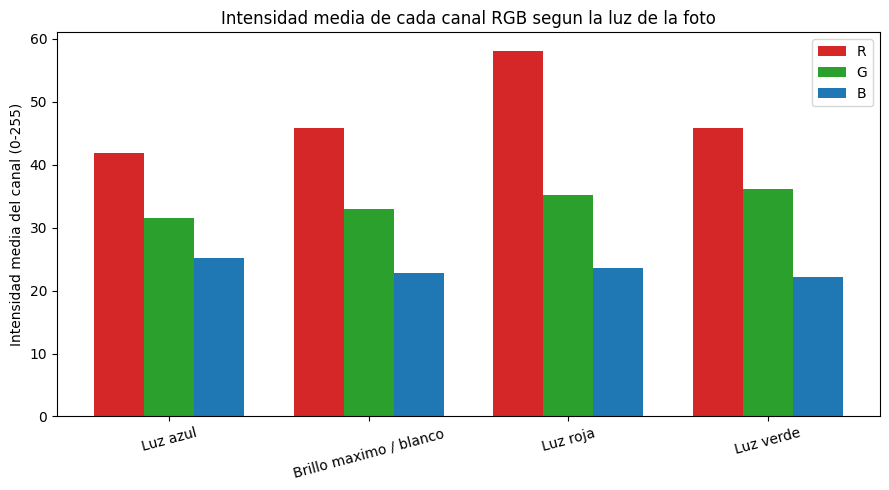

In [ ]:
# Grafico de barras: media de cada canal por condicion de luz (mas facil de comparar de un vistazo)
x = np.arange(len(tabla_canales))
ancho = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - ancho, tabla_canales["R_media"], ancho, label="R", color="tab:red")
ax.bar(x,          tabla_canales["G_media"], ancho, label="G", color="tab:green")
ax.bar(x + ancho,  tabla_canales["B_media"], ancho, label="B", color="tab:blue")
ax.set_xticks(x); ax.set_xticklabels(tabla_canales["condicion_luz"], rotation=15)
ax.set_ylabel("Intensidad media del canal (0-255)")
ax.set_title("Intensidad media de cada canal RGB segun la luz de la foto")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "grafico_barras_canales.png"), dpi=120, bbox_inches="tight")
plt.show()
